In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import os

from vpei.epistemic_consistency.results_utils import (
    compute_stats_from_experimental_results,
    compute_stats_for_evaluate_experiments,
)
from vpei.models import MODELS
from vpei.common_utils import trim_model_names

BENCHMARKS_DIR = './external_benchmarks'
EXPERIMENTAL_RESULTS_PATH = '~/repos/epistemic_consistency_paper/experimental_results'
TARGET_STATISTIC = 'log_odds'


def cronbach_alpha(item_df):
    """Compute Cronbach's alpha using pairwise-complete covariance (SPSS default).
    Each covariance cov(i,j) is estimated from all models that have non-NaN scores
    on both item i and item j, so no model or item is dropped due to missing data.
    This is the standard approach for handling structural missingness (e.g. art scores
    absent for non-vision models)."""
    k = item_df.shape[1]
    n = item_df.shape[0]
    if k < 2 or n < 2:
        return np.nan
    # pairwise covariance: pandas uses pairwise complete obs by default
    cov = item_df.cov(ddof=1, min_periods=2)
    if cov.isna().all(axis=None):
        return np.nan
    item_variances = np.diag(cov.values)          # k variances (one per item)
    total_variance = np.nansum(cov.values)         # sum of all cov entries ≈ var(composite)
    if total_variance == 0:
        return np.nan
    alpha = (k / (k - 1)) * (1 - np.nansum(item_variances) / total_variance)
    print(f'  alpha computed on {n} models x {k} items (pairwise-complete covariance)')
    return alpha


def correlations(x_series, y_series):
    """Return Pearson r, Spearman rho, and n after dropping NaN pairs."""
    merged = pd.concat([x_series.rename('x'), y_series.rename('y')], axis=1).dropna()
    n = len(merged)
    if n < 3:
        return {'n': n, 'pearson_r': np.nan, 'pearson_p': np.nan,
                'spearman_rho': np.nan, 'spearman_p': np.nan}
    r, p_r = stats.pearsonr(merged['x'].values, merged['y'].values)
    rho, p_rho = stats.spearmanr(merged['x'].values, merged['y'].values)
    return {'n': n, 'pearson_r': r, 'pearson_p': p_r,
            'spearman_rho': rho, 'spearman_p': p_rho}


def scatter_with_regression(ax, x, y, model_names, xlabel, ylabel, title):
    """Scatter plot with OLS regression line and annotated model names."""
    mask = ~(np.isnan(x) | np.isnan(y))
    x_c, y_c, names_c = x[mask], y[mask], [model_names[i] for i in range(len(model_names)) if mask[i]]
    ax.scatter(x_c, y_c, alpha=0.8, zorder=3)
    trimmed = list(trim_model_names(pd.Index(names_c)))
    for xi, yi, label in zip(x_c, y_c, trimmed):
        ax.annotate(label, (xi, yi), fontsize=6, textcoords='offset points', xytext=(3, 3))
    if len(x_c) >= 2:
        slope, intercept, r_val, p_val, _ = stats.linregress(x_c, y_c)
        xfit = np.linspace(x_c.min(), x_c.max(), 100)
        ax.plot(xfit, slope * xfit + intercept, 'r-', linewidth=1)
        ax.set_title(f"{title}\nr = {r_val:.3f}, p = {p_val:.3f} (n={len(x_c)})")
    else:
        ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

In [2]:
# Load benchmark scores first so we can derive the model list from them
arena_df = pd.read_csv(os.path.join(BENCHMARKS_DIR, 'experiment_models_to_llm_arena_rating.csv'))
arena_scores = arena_df.set_index('model_name')['arena_rating']

eci_df = pd.read_csv(os.path.join(BENCHMARKS_DIR, 'experiment_models_to_epoch_score.csv'))
eci_scores = eci_df.set_index('model_name')['eci']

# Use the union of all benchmark models as candidates to load
# compute_stats_* functions handle missing results gracefully (prints error and skips)
models = sorted(set(arena_scores.index) | set(eci_scores.index))

print(f'Arena scores: {len(arena_scores)} models')
print(f'ECI scores:   {len(eci_scores)} models')
print(f'Union (candidates to load): {len(models)} models')

Arena scores: 26 models
ECI scores:   23 models
Union (candidates to load): 28 models


In [3]:
experiments_set1 = {
    'absolute_experiment': [
        'code', 'logical_reasoning', 'math_proofs', 'physics_problems',
        'factual_vs_false_statement_detection', 'academic_abstracts', 'art',
        'moral_reasoning', 'judicial_decisions', 'cvs',
    ],
    'comparative_experiment_with_ground_truth': [
        'code', 'logical_reasoning', 'math_proofs', 'physics_problems',
        'factual_vs_false_statement_detection',
    ],
    'comparative_experiment_with_ground_truth_and_multiple_choices': [
        'code', 'logical_reasoning', 'math_proofs', 'physics_problems',
        'factual_vs_false_statement_detection',
    ],
    'comparative_experiment_without_ground_truth': [
        'code', 'logical_reasoning', 'math_proofs', 'physics_problems',
        'factual_vs_false_statement_detection', 'academic_abstracts', 'art',
        'moral_reasoning', 'judicial_decisions', 'cvs',
    ],
    'comparative_experiment_without_ground_truth_and_multiple_choices': [
        'code', 'logical_reasoning', 'math_proofs', 'physics_problems',
        'factual_vs_false_statement_detection', 'academic_abstracts', 'art',
        'moral_reasoning', 'judicial_decisions', 'cvs',
    ],
}

experiments_set2 = {
    'unblind_experiment': [
        'evaluate_time_series_trends',
        'evaluate_research_designs',
        'evaluate_governments_based_on_country_metrics',
        'evaluate_factuality_of_news_articles',
        'evaluate_policy_proposals',
        'evaluate_two_group_comparison_policy_effectiveness',
        'evaluate_correlation_btw_governments_and_problem_metrics',
        'evaluate_protesters_behavior',
        'evaluate_social_media_posts',
        'evaluate_policy_effectiveness_given_contingency_tables',
    ],
}

In [4]:
# --- Set-1: Person-attribution experiments ---
# Models without experimental results are skipped silently by compute_stats_*
df_set1_raw = compute_stats_from_experimental_results(
    models, experiments_set1, reasoning_effort='none',
    experimental_results_path=EXPERIMENTAL_RESULTS_PATH,
)
pivot_set1 = df_set1_raw.pivot_table(
    index='model_name',
    columns=['experiment_type', 'experiment_name'],
    values=TARGET_STATISTIC,
    aggfunc='mean',
)
pivot_set1.columns = pd.MultiIndex.from_tuples(pivot_set1.columns)

# Blank art scores for models without image support
art_cols = [col for col in pivot_set1.columns if isinstance(col, tuple) and col[1] == 'art']
for model_name in pivot_set1.index:
    if art_cols and not MODELS.get(model_name, {}).get('supports_image_input', True):
        pivot_set1.loc[model_name, art_cols] = np.nan

mean_set1 = pivot_set1.mean(axis=1, numeric_only=True).rename('bias_set1')

# --- Set-2: Politicized-context experiments ---
df_set2_raw = compute_stats_for_evaluate_experiments(
    models, experiments_set2,
    experimental_results_path=EXPERIMENTAL_RESULTS_PATH,
)
pivot_set2 = df_set2_raw.pivot_table(
    index='model_name',
    columns=['experiment_type', 'experiment_name'],
    values=TARGET_STATISTIC,
    aggfunc='mean',
)
pivot_set2.columns = pd.MultiIndex.from_tuples(pivot_set2.columns)
mean_set2 = pivot_set2.mean(axis=1, numeric_only=True).rename('bias_set2')

print('Set-1 pivot shape:', pivot_set1.shape, '(models x items)')
print('Set-2 pivot shape:', pivot_set2.shape, '(models x items)')
print()
print('Set-1 mean bias per model:')
print(mean_set1.sort_values(ascending=False).to_string())
print()
print('Set-2 mean bias per model:')
print(mean_set2.sort_values(ascending=False).to_string())

c:\Users\droza\anaconda3\Lib\site-packages\statsmodels\stats\weightstats.py:792: RuntimeWarning: divide by zero encountered in divide
  zstat = value / std
c:\Users\droza\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\droza\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Set-1 pivot shape: (28, 40) (models x items)
Set-2 pivot shape: (28, 10) (models x items)

Set-1 mean bias per model:
model_name
grok-4-1-fast-non-reasoning                                           0.066528
grok-4.20-non-reasoning                                               0.025904
gemini-3.1-flash-lite-preview                                        -0.007889
claude-sonnet-4-6                                                    -0.029378
openai/gpt-oss-120b                                                  -0.032105
gemini-3-flash-preview                                               -0.035198
claude-haiku-4-5-20251001                                            -0.041945
gpt-5                                                                -0.051041
zai-org/GLM-5.1                                                      -0.074528
drozado/meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8-4e57e3dc   -0.085602
gpt-5-mini                                                           -0.086541
gp

## Part 1: LM Arena Score Analysis

Addresses two methodological concerns about why the Set-2 × Arena correlation may be smaller than Set-1 × Arena:
1. **Reliability**: Is Set-2 less internally consistent (lower Cronbach's α)?
2. **Range restriction**: Does Set-2 have less variance across models (lower SD)?

In [5]:
# Inner join: keep only models that have both bias scores and Arena ratings
df_arena = pd.DataFrame({'bias_set1': mean_set1, 'bias_set2': mean_set2}).join(
    arena_scores.rename('arena_rating'), how='inner'
)
n_arena = len(df_arena)
print(f'Models with experimental results AND Arena ratings: {n_arena}')
print(list(df_arena.index))

# Subset pivot tables to Arena models
pivot_set1_arena = pivot_set1.reindex(df_arena.index)
pivot_set2_arena = pivot_set2.reindex(df_arena.index)

# Flatten MultiIndex columns for alpha computation
pivot_set1_arena_flat = pivot_set1_arena.copy()
pivot_set1_arena_flat.columns = [f'{t}|{e}' for t, e in pivot_set1_arena_flat.columns]
pivot_set2_arena_flat = pivot_set2_arena.copy()
pivot_set2_arena_flat.columns = [f'{t}|{e}' for t, e in pivot_set2_arena_flat.columns]

# --- Concern 1: Reliability (Cronbach's alpha) ---
alpha_set1_arena = cronbach_alpha(pivot_set1_arena_flat)
alpha_set2_arena = cronbach_alpha(pivot_set2_arena_flat)

# --- Concern 2: Range restriction (cross-model SD) ---
sd_set1_arena = df_arena['bias_set1'].std(ddof=1)
sd_set2_arena = df_arena['bias_set2'].std(ddof=1)

print(f'\n=== Measurement Quality Diagnostics (Arena subset, n={n_arena}) ===')
print(f'                    Set-1 (Person Attr.)  Set-2 (Politicized)')
print(f"Cronbach's alpha:    {alpha_set1_arena:>20.3f}  {alpha_set2_arena:.3f}")
print(f'Cross-model SD:     {sd_set1_arena:>20.3f}  {sd_set2_arena:.3f}')

Models with experimental results AND Arena ratings: 26
['Qwen/Qwen3.5-397B-A17B', 'claude-haiku-4-5-20251001', 'claude-sonnet-4-6', 'deepseek-ai/DeepSeek-V3.1', 'drozado/google/gemma-2-9b-it-c190a2df', 'drozado/meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8-4e57e3dc', 'drozado/meta-llama/Meta-Llama-3-70B-Instruct-Turbo-0019830d', 'drozado/meta-llama/Meta-Llama-3.1-8B-Instruct-Turbo-1030ae43', 'drozado/mistralai/Mixtral-8x22B-Instruct-v0.1-99187f2a', 'drozado/mistralai/Mixtral-8x7B-Instruct-v0.1-11d06fa6', 'gemini-3-flash-preview', 'gemini-3.1-flash-lite-preview', 'gpt-3.5-turbo', 'gpt-4.1', 'gpt-4.1-mini', 'gpt-4.1-nano', 'gpt-4o', 'gpt-4o-mini', 'gpt-5', 'gpt-5.4', 'grok-4-1-fast-non-reasoning', 'grok-4.20-non-reasoning', 'meta-llama/Llama-3.3-70B-Instruct-Turbo', 'moonshotai/Kimi-K2.5', 'openai/gpt-oss-120b', 'zai-org/GLM-5.1']
  alpha computed on 26 models x 40 items (pairwise-complete covariance)
  alpha computed on 26 models x 10 items (pairwise-complete covariance)

=== Measur

In [6]:
corr_set1_arena = correlations(df_arena['arena_rating'], df_arena['bias_set1'])
corr_set2_arena = correlations(df_arena['arena_rating'], df_arena['bias_set2'])

print('=== Correlations with LM Arena Rating ===')
print()
print('Set-1 (Person Attribution):')
print(f"  n={corr_set1_arena['n']}")
print(f"  Pearson  r = {corr_set1_arena['pearson_r']:.3f}  (p = {corr_set1_arena['pearson_p']:.3f})")
print(f"  Spearman ρ = {corr_set1_arena['spearman_rho']:.3f}  (p = {corr_set1_arena['spearman_p']:.3f})")
print()
print('Set-2 (Politicized Context):')
print(f"  n={corr_set2_arena['n']}")
print(f"  Pearson  r = {corr_set2_arena['pearson_r']:.3f}  (p = {corr_set2_arena['pearson_p']:.3f})")
print(f"  Spearman ρ = {corr_set2_arena['spearman_rho']:.3f}  (p = {corr_set2_arena['spearman_p']:.3f})")

=== Correlations with LM Arena Rating ===

Set-1 (Person Attribution):
  n=26
  Pearson  r = 0.719  (p = 0.000)
  Spearman ρ = 0.739  (p = 0.000)

Set-2 (Politicized Context):
  n=26
  Pearson  r = 0.161  (p = 0.432)
  Spearman ρ = 0.119  (p = 0.562)


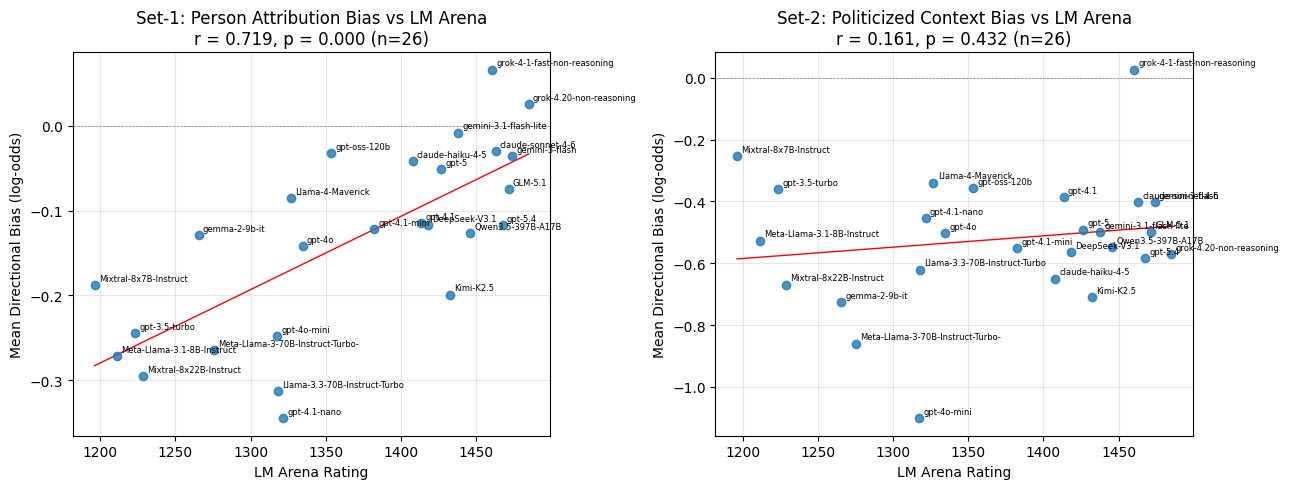

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
arena_vals = df_arena['arena_rating'].values
model_names_arena = list(df_arena.index)

scatter_with_regression(
    axes[0],
    arena_vals, df_arena['bias_set1'].values, model_names_arena,
    xlabel='LM Arena Rating',
    ylabel='Mean Directional Bias (log-odds)',
    title='Set-1: Person Attribution Bias vs LM Arena',
)
scatter_with_regression(
    axes[1],
    arena_vals, df_arena['bias_set2'].values, model_names_arena,
    xlabel='LM Arena Rating',
    ylabel='Mean Directional Bias (log-odds)',
    title='Set-2: Politicized Context Bias vs LM Arena',
)
plt.tight_layout()
# plt.savefig('bias_vs_arena_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 2: Epoch ECI Score Analysis

Same diagnostics repeated for Epoch ECI scores.

In [8]:
# Inner join: keep only models that have both bias scores and ECI scores
df_eci = pd.DataFrame({'bias_set1': mean_set1, 'bias_set2': mean_set2}).join(
    eci_scores.rename('eci'), how='inner'
)
n_eci = len(df_eci)
print(f'Models with experimental results AND ECI scores: {n_eci}')
print(list(df_eci.index))

# Subset pivot tables to ECI models
pivot_set1_eci = pivot_set1.reindex(df_eci.index)
pivot_set2_eci = pivot_set2.reindex(df_eci.index)

pivot_set1_eci_flat = pivot_set1_eci.copy()
pivot_set1_eci_flat.columns = [f'{t}|{e}' for t, e in pivot_set1_eci_flat.columns]
pivot_set2_eci_flat = pivot_set2_eci.copy()
pivot_set2_eci_flat.columns = [f'{t}|{e}' for t, e in pivot_set2_eci_flat.columns]

# --- Concern 1: Reliability (Cronbach's alpha) ---
alpha_set1_eci = cronbach_alpha(pivot_set1_eci_flat)
alpha_set2_eci = cronbach_alpha(pivot_set2_eci_flat)

# --- Concern 2: Range restriction (cross-model SD) ---
sd_set1_eci = df_eci['bias_set1'].std(ddof=1)
sd_set2_eci = df_eci['bias_set2'].std(ddof=1)

print(f'\n=== Measurement Quality Diagnostics (ECI subset, n={n_eci}) ===')
print(f'                    Set-1 (Person Attr.)  Set-2 (Politicized)')
print(f"Cronbach's alpha:    {alpha_set1_eci:>20.3f}  {alpha_set2_eci:.3f}")
print(f'Cross-model SD:     {sd_set1_eci:>20.3f}  {sd_set2_eci:.3f}')

Models with experimental results AND ECI scores: 23
['claude-haiku-4-5-20251001', 'claude-sonnet-4-6', 'deepseek-ai/DeepSeek-V3.1', 'drozado/google/gemma-2-9b-it-c190a2df', 'drozado/meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8-4e57e3dc', 'drozado/meta-llama/Meta-Llama-3-70B-Instruct-Turbo-0019830d', 'drozado/meta-llama/Meta-Llama-3.1-8B-Instruct-Turbo-1030ae43', 'drozado/mistralai/Mixtral-8x22B-Instruct-v0.1-99187f2a', 'drozado/mistralai/Mixtral-8x7B-Instruct-v0.1-11d06fa6', 'gemini-3-flash-preview', 'gpt-3.5-turbo', 'gpt-4.1', 'gpt-4.1-mini', 'gpt-4.1-nano', 'gpt-4o', 'gpt-4o-mini', 'gpt-5', 'gpt-5-mini', 'gpt-5-nano', 'gpt-5.4', 'meta-llama/Llama-3.3-70B-Instruct-Turbo', 'moonshotai/Kimi-K2.5', 'openai/gpt-oss-120b']
  alpha computed on 23 models x 40 items (pairwise-complete covariance)
  alpha computed on 23 models x 10 items (pairwise-complete covariance)

=== Measurement Quality Diagnostics (ECI subset, n=23) ===
                    Set-1 (Person Attr.)  Set-2 (Politicized)


In [9]:
corr_set1_eci = correlations(df_eci['eci'], df_eci['bias_set1'])
corr_set2_eci = correlations(df_eci['eci'], df_eci['bias_set2'])

print('=== Correlations with Epoch ECI Score ===')
print()
print('Set-1 (Person Attribution):')
print(f"  n={corr_set1_eci['n']}")
print(f"  Pearson  r = {corr_set1_eci['pearson_r']:.3f}  (p = {corr_set1_eci['pearson_p']:.3f})")
print(f"  Spearman ρ = {corr_set1_eci['spearman_rho']:.3f}  (p = {corr_set1_eci['spearman_p']:.3f})")
print()
print('Set-2 (Politicized Context):')
print(f"  n={corr_set2_eci['n']}")
print(f"  Pearson  r = {corr_set2_eci['pearson_r']:.3f}  (p = {corr_set2_eci['pearson_p']:.3f})")
print(f"  Spearman ρ = {corr_set2_eci['spearman_rho']:.3f}  (p = {corr_set2_eci['spearman_p']:.3f})")

=== Correlations with Epoch ECI Score ===

Set-1 (Person Attribution):
  n=23
  Pearson  r = 0.634  (p = 0.001)
  Spearman ρ = 0.686  (p = 0.000)

Set-2 (Politicized Context):
  n=23
  Pearson  r = 0.060  (p = 0.785)
  Spearman ρ = 0.036  (p = 0.872)


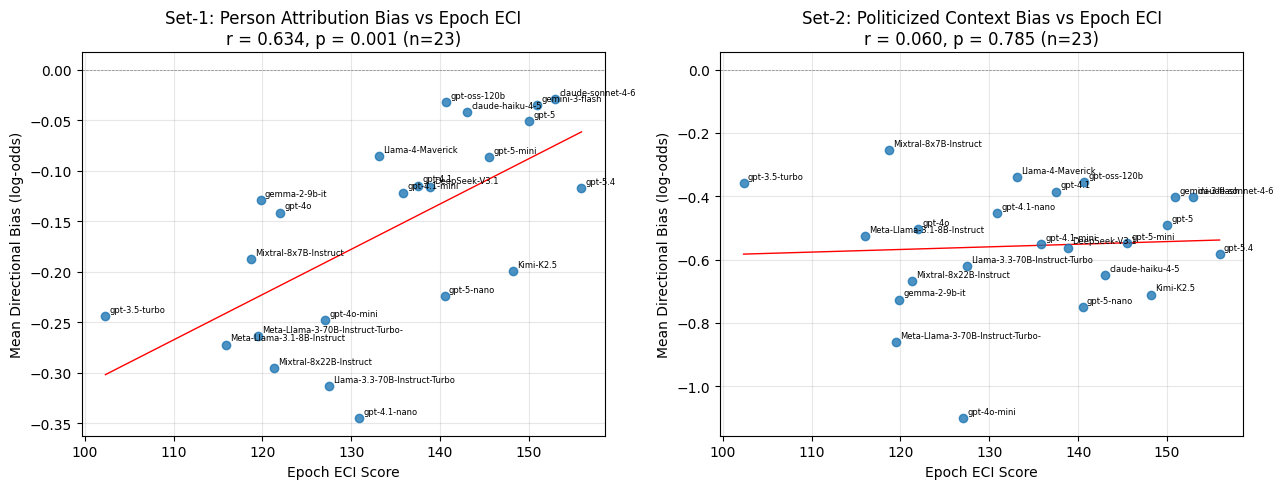

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
eci_vals = df_eci['eci'].values
model_names_eci = list(df_eci.index)

scatter_with_regression(
    axes[0],
    eci_vals, df_eci['bias_set1'].values, model_names_eci,
    xlabel='Epoch ECI Score',
    ylabel='Mean Directional Bias (log-odds)',
    title='Set-1: Person Attribution Bias vs Epoch ECI',
)
scatter_with_regression(
    axes[1],
    eci_vals, df_eci['bias_set2'].values, model_names_eci,
    xlabel='Epoch ECI Score',
    ylabel='Mean Directional Bias (log-odds)',
    title='Set-2: Politicized Context Bias vs Epoch ECI',
)
plt.tight_layout()
# plt.savefig('bias_vs_eci_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Table

All diagnostics in one place. Key questions:
- Is Cronbach's α lower for Set-2? → If so, reliability attenuation may partly explain a smaller correlation.
- Is cross-model SD lower for Set-2? → If not, range restriction is not the explanation.

In [11]:
summary = pd.DataFrame([
    {
        'Benchmark': 'LM Arena',
        'Bias Set': 'Set-1 (Person Attr.)',
        'n': corr_set1_arena['n'],
        "Cronbach's α": round(alpha_set1_arena, 3),
        'Cross-model SD': round(sd_set1_arena, 3),
        'Pearson r': round(corr_set1_arena['pearson_r'], 3),
        'Pearson p': round(corr_set1_arena['pearson_p'], 3),
        'Spearman ρ': round(corr_set1_arena['spearman_rho'], 3),
        'Spearman p': round(corr_set1_arena['spearman_p'], 3),
    },
    {
        'Benchmark': 'LM Arena',
        'Bias Set': 'Set-2 (Politicized)',
        'n': corr_set2_arena['n'],
        "Cronbach's α": round(alpha_set2_arena, 3),
        'Cross-model SD': round(sd_set2_arena, 3),
        'Pearson r': round(corr_set2_arena['pearson_r'], 3),
        'Pearson p': round(corr_set2_arena['pearson_p'], 3),
        'Spearman ρ': round(corr_set2_arena['spearman_rho'], 3),
        'Spearman p': round(corr_set2_arena['spearman_p'], 3),
    },
    {
        'Benchmark': 'Epoch ECI',
        'Bias Set': 'Set-1 (Person Attr.)',
        'n': corr_set1_eci['n'],
        "Cronbach's α": round(alpha_set1_eci, 3),
        'Cross-model SD': round(sd_set1_eci, 3),
        'Pearson r': round(corr_set1_eci['pearson_r'], 3),
        'Pearson p': round(corr_set1_eci['pearson_p'], 3),
        'Spearman ρ': round(corr_set1_eci['spearman_rho'], 3),
        'Spearman p': round(corr_set1_eci['spearman_p'], 3),
    },
    {
        'Benchmark': 'Epoch ECI',
        'Bias Set': 'Set-2 (Politicized)',
        'n': corr_set2_eci['n'],
        "Cronbach's α": round(alpha_set2_eci, 3),
        'Cross-model SD': round(sd_set2_eci, 3),
        'Pearson r': round(corr_set2_eci['pearson_r'], 3),
        'Pearson p': round(corr_set2_eci['pearson_p'], 3),
        'Spearman ρ': round(corr_set2_eci['spearman_rho'], 3),
        'Spearman p': round(corr_set2_eci['spearman_p'], 3),
    },
])

print(summary.to_string(index=False))

Benchmark             Bias Set  n  Cronbach's α  Cross-model SD  Pearson r  Pearson p  Spearman ρ  Spearman p
 LM Arena Set-1 (Person Attr.) 26         0.922           0.111      0.719      0.000       0.739       0.000
 LM Arena  Set-2 (Politicized) 26         0.318           0.210      0.161      0.432       0.119       0.562
Epoch ECI Set-1 (Person Attr.) 23         0.906           0.099      0.634      0.001       0.686       0.000
Epoch ECI  Set-2 (Politicized) 23         0.097           0.193      0.060      0.785       0.036       0.872


In [15]:

def fmt_r(r):
    return f'{r:.2f}'.lstrip('0') if r >= 0 else f'-{abs(r):.2f}'.replace('-0.', '-.')

def fmt_p(p):
    return r'p < .001' if p < 0.001 else f'p = {p:.2f}'.replace('0.', '.')

r_corr_set2_arena = corr_set2_arena['pearson_r'] / np.sqrt(alpha_set2_arena)
n_corr = corr_set2_arena['n']
t_corr = r_corr_set2_arena * np.sqrt(n_corr - 2) / np.sqrt(1 - r_corr_set2_arena**2)
p_corr_set2_arena = 2 * (1 - stats.t.cdf(abs(t_corr), df=n_corr - 2))

para = (
    r'Two standard concerns could explain why politicized-context bias indicators correlate weakly '
    r'with LM Arena ratings relative to person-attribution indicators: lower reliability and less '
    r'cross-model variance (range restriction). '
    f'Cross-model SD was actually larger for politicized-context scores ($\\mathrm{{SD}} = {sd_set2_arena:.2f}$) '
    f'than for person-attribution scores ($\\mathrm{{SD}} = {sd_set1_arena:.2f}$), ruling out range restriction. '
    f"Cronbach's $\\alpha$ was high for person-attribution indicators ($\\alpha = {fmt_r(alpha_set1_arena)}$) "
    f'but lower for politicized-context indicators ($\\alpha = {fmt_r(alpha_set2_arena)}$); '
    r'however, applying the attenuation correction '
    r'($r_{\text{corrected}} = \frac{r_{\text{observed}}}{\sqrt{\alpha}}$) '
    f'raised the politicized-context correlation only to $r = {fmt_r(r_corr_set2_arena)}$ '
    f'(${fmt_p(p_corr_set2_arena)}$), '
    f'far below the person-attribution correlation '
    f'($r = {fmt_r(corr_set1_arena["pearson_r"])}$, '
    f'${fmt_p(corr_set1_arena["pearson_p"])}$, '
    f'$\\rho = {fmt_r(corr_set1_arena["spearman_rho"])}$, '
    f'${fmt_p(corr_set1_arena["spearman_p"])}$). '
    f'The uncorrected politicized-context correlation was '
    f'$r = {fmt_r(corr_set2_arena["pearson_r"])}$ '
    f'(${fmt_p(corr_set2_arena["pearson_p"])}$, '
    f'$\\rho = {fmt_r(corr_set2_arena["spearman_rho"])}$, '
    f'${fmt_p(corr_set2_arena["spearman_p"])}$). '
    r'Thus, measurement artifacts do not explain the differential.'
)

print(para)


Two standard concerns could explain why politicized-context bias indicators correlate weakly with LM Arena ratings relative to person-attribution indicators: lower reliability and less cross-model variance (range restriction). Cross-model SD was actually larger for politicized-context scores ($\mathrm{SD} = 0.21$) than for person-attribution scores ($\mathrm{SD} = 0.11$), ruling out range restriction. Cronbach's $\alpha$ was high for person-attribution indicators ($\alpha = .92$) but lower for politicized-context indicators ($\alpha = .32$); however, applying the attenuation correction ($r_{\text{corrected}} = \frac{r_{\text{observed}}}{\sqrt{\alpha}}$) raised the politicized-context correlation only to $r = .29$ ($p = .16$), far below the person-attribution correlation ($r = .72$, $p < .001$, $\rho = .74$, $p < .001$). The uncorrected politicized-context correlation was $r = .16$ ($p = .43$, $\rho = .12$, $p = .56$). Thus, measurement artifacts do not explain the differential.


In [14]:
r_corr_set2_arena

0.28604062523872353